In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, AffinityPropagation, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
df = pd.read_csv('Wholesale customers data.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nSummary statistics:")
print(df.describe())

print(f"\nMissing values: {df.isnull().sum().sum()}")

X = df.drop(['Channel', 'Region'], axis=1)  # Using only product categories

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Shape after scaling: {X_scaled_df.shape}")

distance_matrix = pdist(X_scaled, metric='euclidean')

print(f"Distance matrix shape: {len(distance_matrix)} pairs")
print(f"Distance range: [{distance_matrix.min():.4f}, {distance_matrix.max():.4f}]")
print(f"Mean distance: {distance_matrix.mean():.4f}")
print(f"Std distance: {distance_matrix.std():.4f}")

Dataset shape: (440, 8)

First 5 rows:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

Summary statistics:
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1

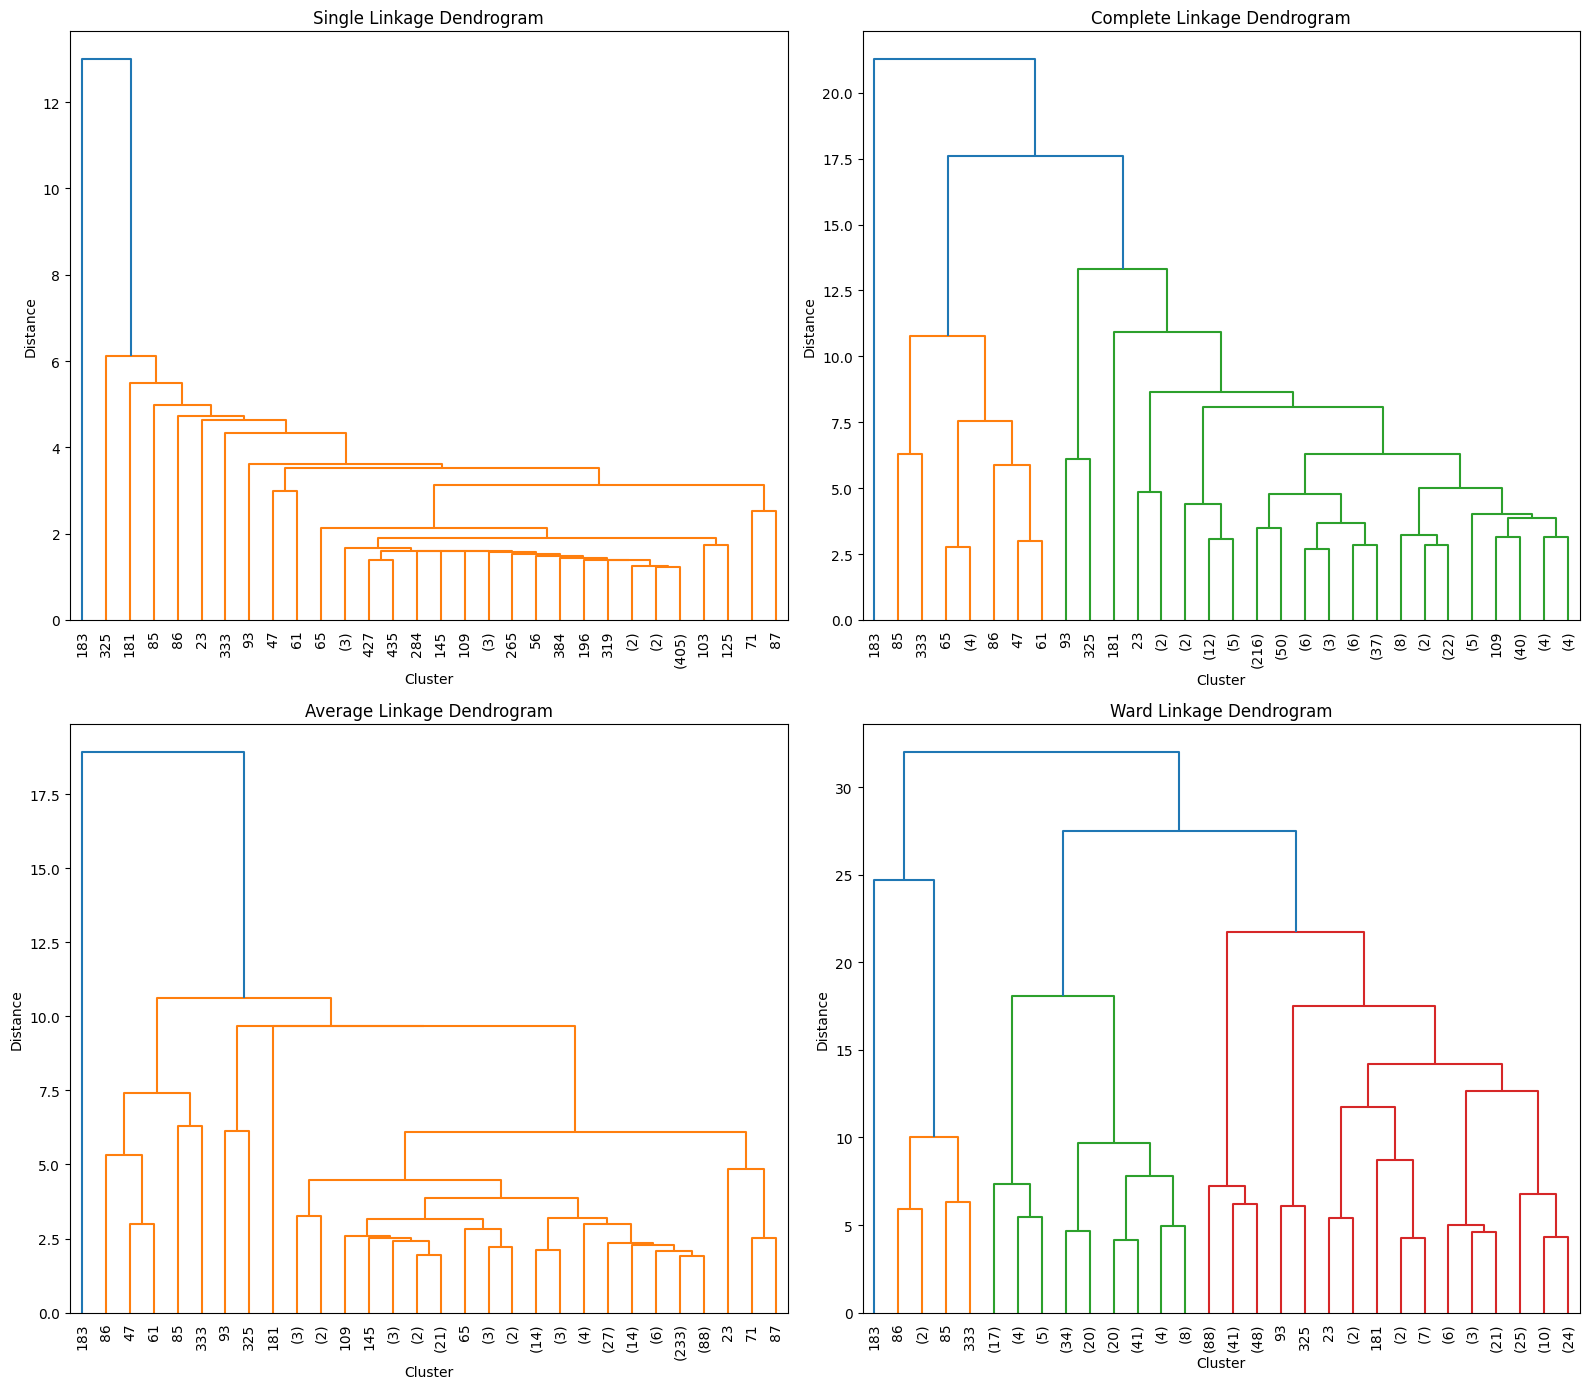

     Linkage  k  Silhouette
8    average  3      0.7676
5   complete  4      0.7119
0     single  3      0.7966
13      ward  4      0.2670


In [3]:
def wholesale_hierarchical_clustering(X_scaled, df_original):

    linkage_methods = ['single', 'complete', 'average', 'ward']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.ravel()
    
    results = []
    
    for i, method in enumerate(linkage_methods):

        if method == 'ward':
            Z = linkage(X_scaled, method=method, metric='euclidean')
        else:
            Z = linkage(X_scaled, method=method)

        axes[i].set_title(f'{method.capitalize()} Linkage Dendrogram')
        dendrogram(Z, ax=axes[i], truncate_mode='lastp', p=30, leaf_rotation=90)
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel('Distance')

        last_distances = Z[-15:, 2]

        for k in [3, 4, 5, 6]:
            clusters = fcluster(Z, t=k, criterion='maxclust')
            if len(set(clusters)) > 1:
                sil = silhouette_score(X_scaled, clusters)
                results.append({
                    'Linkage': method,
                    'k': k,
                    'Silhouette': round(sil, 4)
                })
    
    plt.tight_layout()
    plt.show()

    results_df = pd.DataFrame(results)
    best = results_df.loc[results_df.groupby('Linkage')['Silhouette'].idxmax()]
    print(best)
    
    return results_df

hc_results = wholesale_hierarchical_clustering(X_scaled, df)

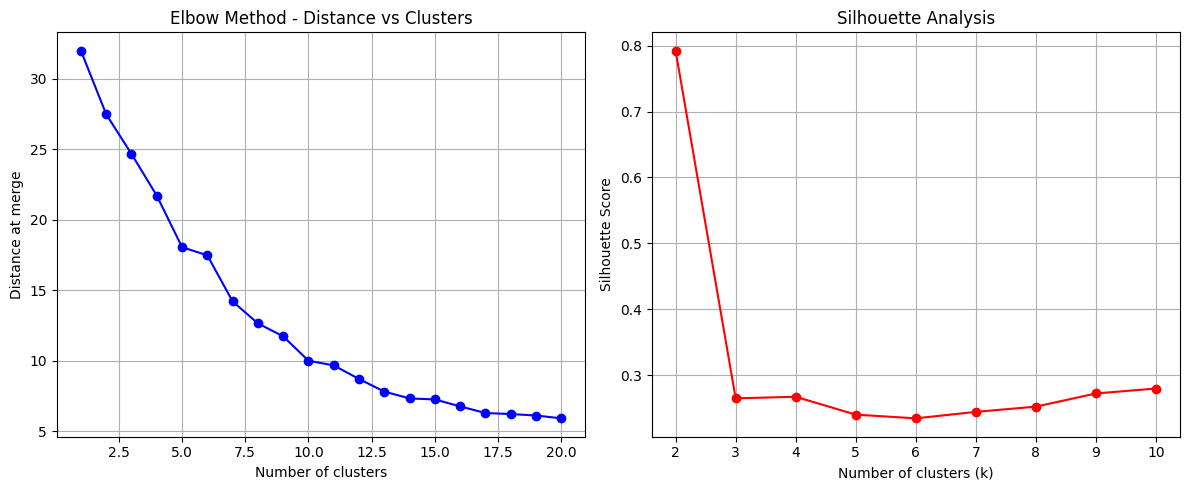


Optimal number of clusters (by silhouette): 2
Best silhouette score: 0.7925


In [4]:
def find_optimal_clusters_hierarchical(X_scaled):
    
    Z = linkage(X_scaled, method='ward')

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    last_distances = Z[-20:, 2]
    plt.plot(range(1, len(last_distances) + 1), last_distances[::-1], 'bo-')
    plt.xlabel('Number of clusters')
    plt.ylabel('Distance at merge')
    plt.title('Elbow Method - Distance vs Clusters')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    k_range = range(2, 11)
    sil_scores = []
    
    for k in k_range:
        clusters = fcluster(Z, t=k, criterion='maxclust')
        if len(set(clusters)) > 1:
            sil = silhouette_score(X_scaled, clusters)
            sil_scores.append(sil)
        else:
            sil_scores.append(-1)
    
    plt.plot(k_range, sil_scores, 'ro-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Analysis')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    optimal_k = k_range[np.argmax(sil_scores)]
    print(f"\nOptimal number of clusters (by silhouette): {optimal_k}")
    print(f"Best silhouette score: {max(sil_scores):.4f}")
    
    return optimal_k

optimal_k = find_optimal_clusters_hierarchical(X_scaled)

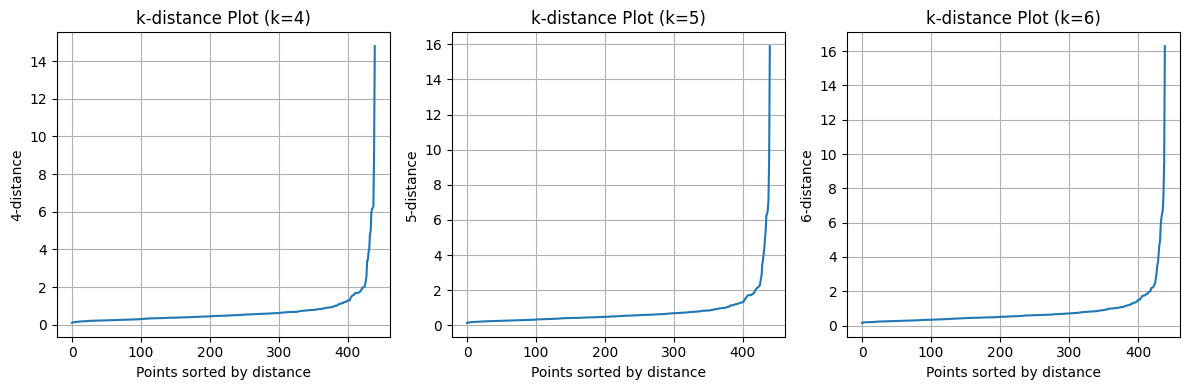

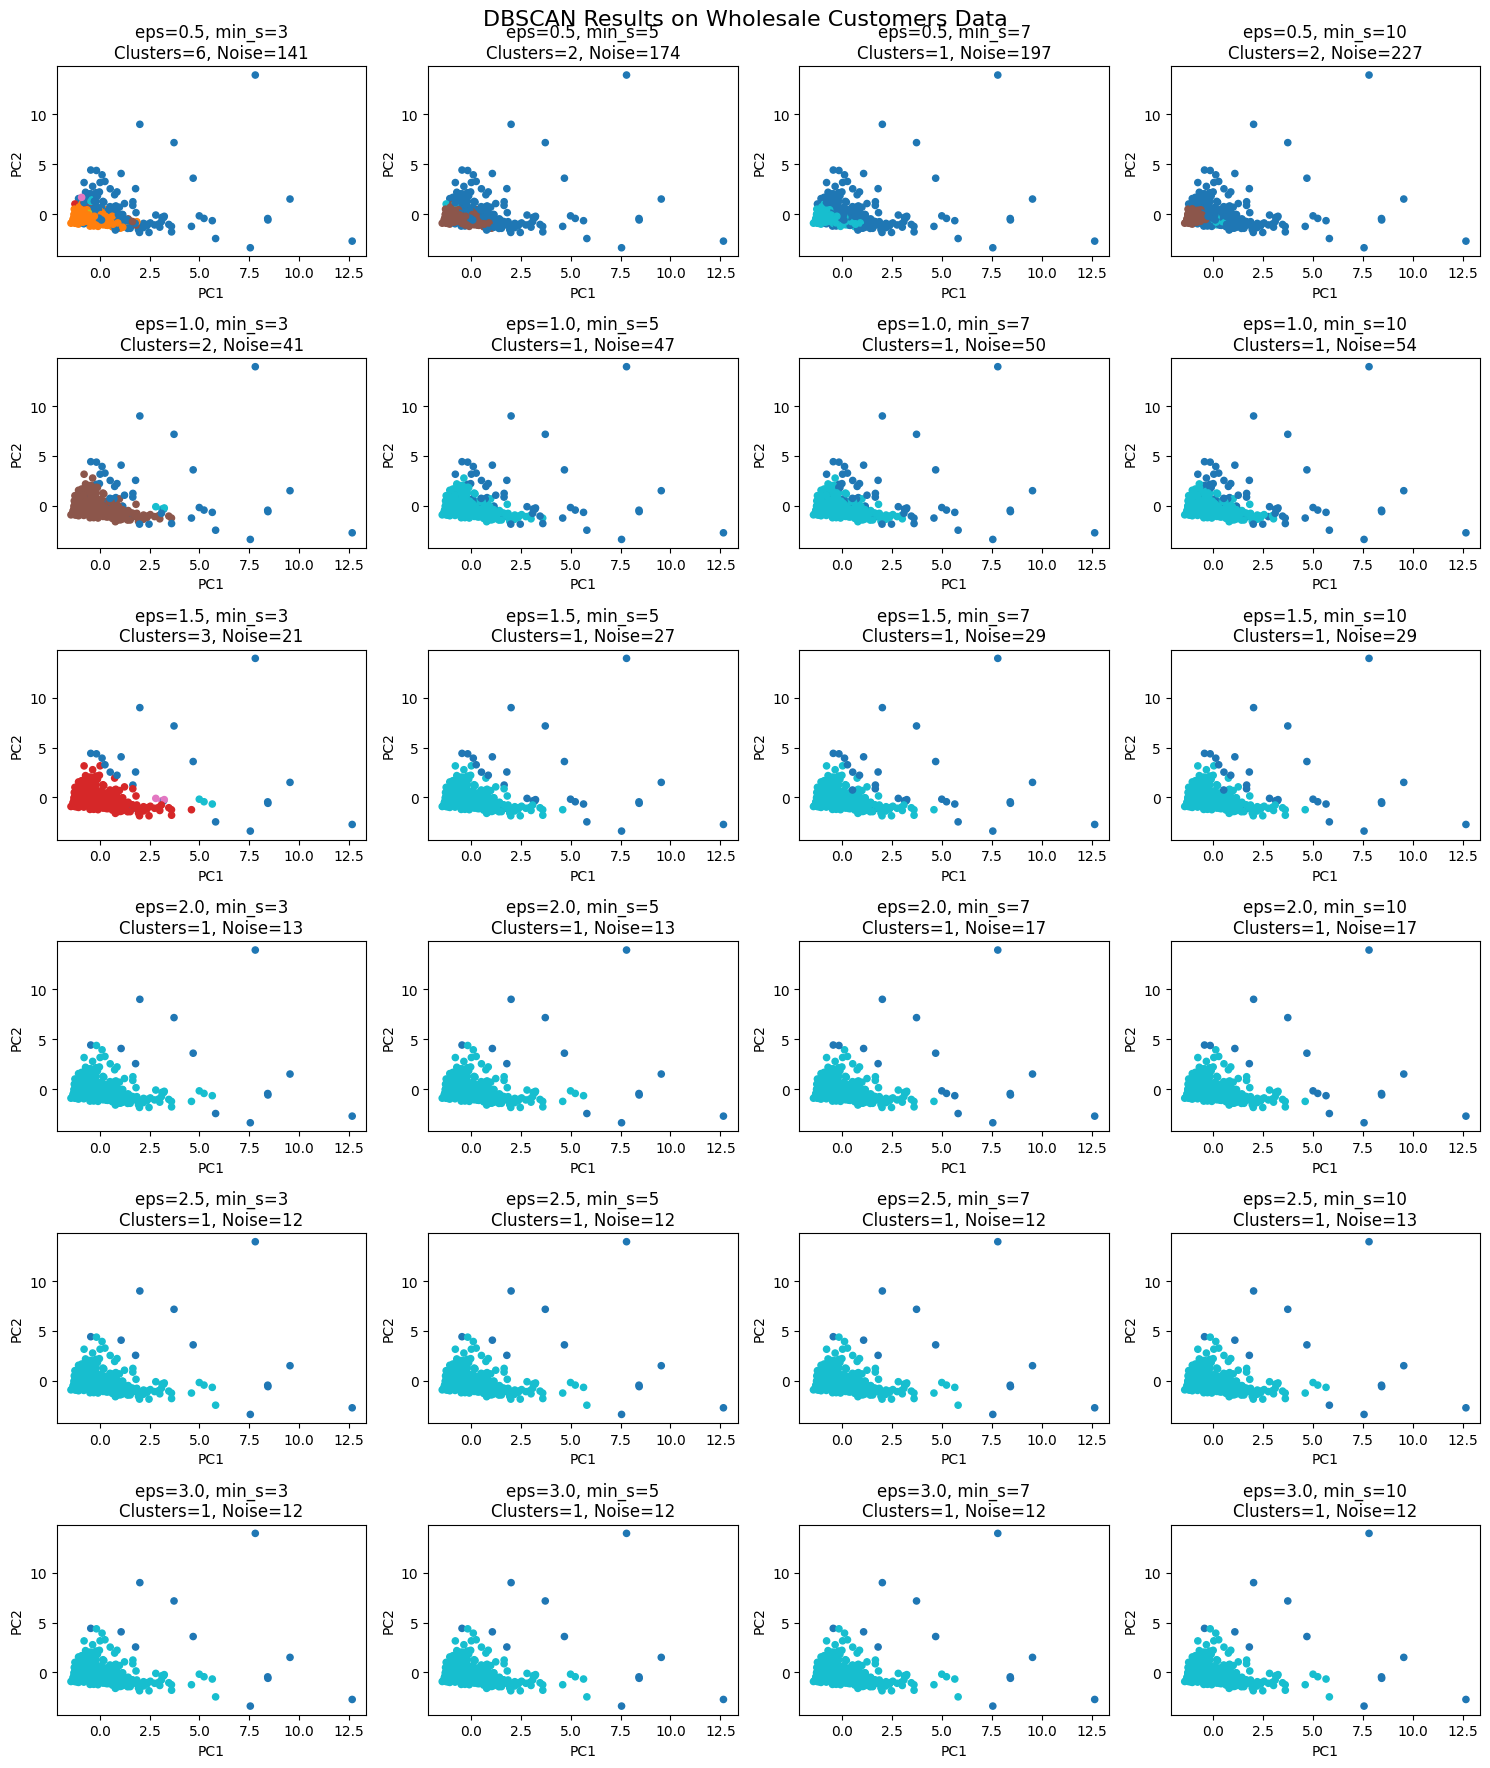


DBSCAN Results Summary:
   eps  min_samples  Clusters  Noise Points  Silhouette
8  1.5            3         3            21      0.4213
4  1.0            3         2            41      0.4164
1  0.5            5         2           174      0.1958
3  0.5           10         2           227     -0.0146
0  0.5            3         6           141     -0.0733
2  0.5            7         1           197     -1.0000
6  1.0            7         1            50     -1.0000
5  1.0            5         1            47     -1.0000
7  1.0           10         1            54     -1.0000
9  1.5            5         1            27     -1.0000

Best DBSCAN Parameters:
eps=1.5, min_samples=3.0
Clusters: 3.0, Noise: 21.0
Silhouette Score: 0.4213


In [5]:
def wholesale_dbscan_analysis(X_scaled, df_original):

    plt.figure(figsize=(12, 4))
    
    for i, k in enumerate([4, 5, 6]):
        neigh = NearestNeighbors(n_neighbors=k)
        neigh.fit(X_scaled)
        distances, indices = neigh.kneighbors(X_scaled)
        k_dist = np.sort(distances[:, k-1])
        
        plt.subplot(1, 3, i+1)
        plt.plot(range(len(k_dist)), k_dist)
        plt.xlabel('Points sorted by distance')
        plt.ylabel(f'{k}-distance')
        plt.title(f'k-distance Plot (k={k})')
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
    min_samples_values = [3, 5, 7, 10]
    
    results = []
    
    fig, axes = plt.subplots(len(eps_values), len(min_samples_values), 
                             figsize=(15, 18))
    
    for i, eps in enumerate(eps_values):
        for j, min_s in enumerate(min_samples_values):
            db = DBSCAN(eps=eps, min_samples=min_s)
            labels = db.fit_predict(X_scaled)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = np.sum(labels == -1)
            
            if n_clusters > 1:
                sil = silhouette_score(X_scaled, labels)
            else:
                sil = -1
            
            results.append({
                'eps': eps,
                'min_samples': min_s,
                'Clusters': n_clusters,
                'Noise Points': n_noise,
                'Silhouette': round(sil, 4)
            })

            from sklearn.decomposition import PCA
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(X_scaled)
            
            ax = axes[i, j]
            scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=20)
            ax.set_title(f'eps={eps}, min_s={min_s}\nClusters={n_clusters}, Noise={n_noise}')
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')
    
    plt.suptitle('DBSCAN Results on Wholesale Customers Data', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    results_df = pd.DataFrame(results)
    print("\nDBSCAN Results Summary:")
    print(results_df.sort_values('Silhouette', ascending=False).head(10))

    best = results_df.loc[results_df['Silhouette'].idxmax()]
    print("\nBest DBSCAN Parameters:")
    print(f"eps={best['eps']}, min_samples={best['min_samples']}")
    print(f"Clusters: {best['Clusters']}, Noise: {best['Noise Points']}")
    print(f"Silhouette Score: {best['Silhouette']}")
    
    return results_df

dbscan_wholesale_results = wholesale_dbscan_analysis(X_scaled, df)